# 01 - Análisis Exploratorio del Sistema HR Core

## Objetivo

En este notebook se realizará un análisis exploratorio del conjunto de datos proveniente del sistema HR Core de GlobalStay Hotels.

El objetivo es comprender la estructura del dataset, identificar problemas de calidad de datos y obtener una visión general de la información antes de comenzar el proceso ETL.

Este análisis corresponde al Sprint 2 del proyecto.

## Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Cuando Pandas imprime un DataFrame grande suele ocultar columnas.

Nosotros queremos ver todo.

No es una cuestión estética.

Es una necesidad durante el análisis exploratorio.

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

### Carga del Dataset

In [9]:
from pathlib import Path

file_path = "../data/raw/hr_core_employees.csv"

df = pd.read_csv(file_path)


#### Verificamos que se haya cargado...

In [11]:
file_path = Path("../data/raw/hr_core_employees.csv")

print(file_path.exists())

True


## Carga del Dataset

El archivo utilizado corresponde al sistema HR Core.

Este sistema representa la fuente principal de información de empleados dentro de la organización.

Contiene información demográfica, contractual, organizacional y laboral de cada empleado.

## Primera Inspección:

In [ ]:
df.head() # muestra las primeras 5 filas del dataframe
df.info() # muestra información general del dataframe, incluyendo el número de filas, columnas, tipos de datos y valores nulos
df.describe() # muestra estadísticas descriptivas para las columnas numéricas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2715 entries, 0 to 2714
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   employee_id       2715 non-null   object
 1   first_name        2715 non-null   object
 2   last_name         2715 non-null   object
 3   gender            2715 non-null   object
 4   birth_date        2715 non-null   object
 5   hire_date         2715 non-null   object
 6   termination_date  299 non-null    object
 7   status            2715 non-null   object
 8   hotel_code        2715 non-null   object
 9   hotel_name        2715 non-null   object
 10  city              2715 non-null   object
 11  country           2715 non-null   object
 12  department_code   2715 non-null   object
 13  department_name   2715 non-null   object
 14  contract_type     2715 non-null   object
 15  hierarchy_level   2715 non-null   object
dtypes: object(16)
memory usage: 339.5+ KB


,employee_id,first_name,last_name,gender,birth_date,hire_date,termination_date,status,hotel_code,hotel_name,city,country,department_code,department_name,contract_type,hierarchy_level
count,2715,2715,2715,2715,2715,2715,299,2715,2715,2715,2715,2715,2715,2715,2715,2715
unique,2700,25,256,6,2451,1589,271,5,11,9,9,4,10,10,4,4
top,EMP00529,Valentina,Garcia Rodriguez,Female,2030-05-10,2023-09-19,2024-07-05,Active,HDR001,GlobalStay Punta Cana Resort,Punta Cana,Spain,HK,Housekeeping,Permanent,Staff
freq,2,160,22,1423,5,6,3,2378,398,401,401,1208,706,706,1792,2035


#### ¿Cuántos registros existen?

In [ ]:
df.shape # muestra el número de filas y columnas del dataframe

(2715, 16)



## Interpretación de la estructura del dataset

La inspección inicial del DataFrame muestra que el conjunto de datos contiene **2715 registros** y **16 columnas**, coincidiendo con el diseño esperado del sistema HR Core.

No se observan valores nulos en las columnas principales. La única excepción es `termination_date`, que presenta **299 valores no nulos**. Esto no representa un problema de calidad, ya que únicamente los empleados que han finalizado su relación laboral deben tener una fecha de baja registrada.

Por otra parte, se observa que las columnas `birth_date`, `hire_date` y `termination_date` fueron interpretadas por Pandas como tipo `object` (texto). En una etapa posterior del proceso ETL será necesario convertirlas al tipo `datetime` para facilitar análisis temporales y cálculos relacionados con antigüedad, edad y rotación del personal.


## Interpretación del resumen estadístico

El resumen descriptivo confirma que la estructura general del dataset coincide con el modelo de negocio definido para GlobalStay Hotels.

Se identifican:

- 2.715 registros.
- 4 países.
- 9 hoteles oficiales y 2 códigos de hotel inconsistentes introducidos deliberadamente para simular problemas de calidad.
- 10 departamentos.
- 4 tipos de contrato.
- 4 niveles jerárquicos.

Asimismo, la columna `termination_date` presenta únicamente 299 valores informados, lo cual es consistente con empleados que ya no forman parte de la organización y no representa un problema de calidad de datos.

# 02 - Verificación de la calidad de los datos

In [18]:
df.duplicated().sum()


np.int64(14)

In [19]:
df["employee_id"].duplicated().sum()

np.int64(15)

In [ ]:
df.duplicated().sum() # ¿Cuántos registros duplicados hay además del original?

df["employee_id"].duplicated().sum() # 

duplicados = df[df["employee_id"].duplicated(keep=False)] # Muéstrame todos los registros involucrados en duplicados.

duplicados.sort_values("employee_id")

,employee_id,first_name,last_name,gender,birth_date,hire_date,termination_date,status,hotel_code,hotel_name,city,country,department_code,department_name,contract_type,hierarchy_level
528,EMP00529,Miguel,Vargas Castro,Male,1976-06-26,2025-05-04,NaN,Active,HES002,GlobalStay Madrid Business,Madrid,Spain,HK,Housekeeping,Permanent,Staff
2711,EMP00529,Miguel,Vargas Castro,Male,1976-06-26,2025-05-04,NaN,Active,HES002,GlobalStay Madrid Business,Madrid,Spain,HK,Housekeeping,Permanent,Staff
565,EMP00566,Andres,Gonzalez Martinez,Male,1979-11-27,2023-10-07,NaN,Active,HES002,GlobalStay Madrid Business,Madrid,Spain,SW,Spa & Wellness,Temporary,Supervisor
2705,EMP00566,Andres,Gonzalez Martinez,Male,1979-11-27,2023-10-07,NaN,Active,HES002,GlobalStay Madrid Business,Madrid,Spain,SW,Spa & Wellness,Temporary,Supervisor
700,EMP00701,Carmen,Perez Garcia,Female,1974-11-11,2020-08-27,NaN,Active,HES003,GlobalStay Barcelona Beach,Barcelona,Spain,FD,Front Desk,Temporary,Staff
2709,EMP00701,Carmen,Perez Garcia,Female,1974-11-11,2020-08-27,NaN,Active,HES003,GlobalStay Barcelona Beach,Barcelona,Spain,FD,Front Desk,Temporary,Staff
812,EMP00813,Maria,Castro Garcia,Female,1998-06-10,2024-05-31,NaN,Active,HES003,GlobalStay Barcelona Beach,Barcelona,Spain,HK,Housekeeping,Temporary,Staff
2703,EMP00813,Maria,Castro Garcia,Female,1998-06-10,2024-05-31,NaN,Active,HES003,GlobalStay Barcelona Beach,Barcelona,Spain,HK,Housekeeping,Temporary,Staff
2706,EMP00846,Carmen,Ramirez Torres,Female,1981-12-08,2021-04-01,NaN,Active,HES003,GlobalStay Barcelona Beach,Barcelona,Spain,FD,Front Desk,Permanent,Staff
845,EMP00846,Carmen,Ramirez Torres,Female,1981-12-08,2021-04-01,NaN,Active,HES003,GlobalStay Barcelona Beach,Barcelona,Spain,FD,Front Desk,Permanent,Staff


## Interpretación

La auditoría del identificador único (`employee_id`) permitió detectar **15 registros duplicados**, correspondientes a **30 filas** en el dataset.

Estos duplicados fueron incorporados de forma intencional durante la generación de datos para simular un escenario real de baja calidad de datos.

Si este problema no se resolviera antes del proceso ETL, afectaría directamente indicadores críticos como el Headcount, el coste de nómina y la tasa de rotación del personal.

### Guardamos estos registros en un archivo


In [22]:
duplicados.to_csv(
    "../reports/sprint_02/duplicated_records.csv",
    index=False
)

## Auditoría de valores nulos

En esta sección verificaremos si existen columnas con valores faltantes.

No todos los valores nulos representan un problema de calidad. Algunas columnas pueden admitir valores vacíos como parte de la lógica del negocio. Por este motivo, analizaremos cada caso antes de determinar si constituye una incidencia.

In [23]:
df.isnull().sum()

employee_id            0
first_name             0
last_name              0
gender                 0
birth_date             0
hire_date              0
termination_date    2416
status                 0
hotel_code             0
hotel_name             0
city                   0
country                0
department_code        0
department_name        0
contract_type          0
hierarchy_level        0
dtype: int64

#### Calculamos el porcentaje de la cantidad de valores nulos

In [24]:
null_percentage = (df.isnull().sum() / len(df) * 100).round(2)

null_percentage

employee_id          0.00
first_name           0.00
last_name            0.00
gender               0.00
birth_date           0.00
hire_date            0.00
termination_date    88.99
status               0.00
hotel_code           0.00
hotel_name           0.00
city                 0.00
country              0.00
department_code      0.00
department_name      0.00
contract_type        0.00
hierarchy_level      0.00
dtype: float64

### Tabla Comparativa de valores nulos

In [27]:
missing_values = (
    pd.DataFrame({
        "Valores nulos": df.isnull().sum(),
        "Porcentaje (%)": (df.isnull().sum() / len(df) * 100).round(2)
    })
    .reset_index()
    .rename(columns={"index": "Columna"})
)

missing_values

,Columna,Valores nulos,Porcentaje (%)
0,employee_id,0,0.00
1,first_name,0,0.00
2,last_name,0,0.00
3,gender,0,0.00
4,birth_date,0,0.00
5,hire_date,0,0.00
6,termination_date,2416,88.99
7,status,0,0.00
8,hotel_code,0,0.00
9,hotel_name,0,0.00


## Interpretación

La auditoría de valores nulos muestra que todas las columnas obligatorias presentan un 100 % de completitud.

La única excepción es `termination_date`, que contiene un 88,99 % de valores nulos.

Este comportamiento es consistente con las reglas de negocio del sistema HR Core, ya que únicamente los empleados que han finalizado su relación laboral deben tener una fecha de baja registrada.

En consecuencia, estos valores nulos no representan un problema de calidad de datos.

## 03 - AUDITORÍA DE VALORES INCONSISTENTES

### Auditoría de valores de la columna `gender`

El objetivo de esta auditoría es verificar que las categorías del atributo `gender` sean consistentes y estén estandarizadas.

Las inconsistencias en valores categóricos pueden provocar errores en indicadores y visualizaciones, generando categorías duplicadas que representan el mismo concepto.

In [28]:
df["gender"].unique()

array(['Female', 'Male', 'Non Binary', 'male', 'M', 'F'], dtype=object)

In [29]:
df["gender"].value_counts()

gender
Female        1423
Male          1247
Non Binary      25
male             7
M                7
F                6
Name: count, dtype: int64

## Interpretación

La auditoría de la columna `gender` permitió identificar seis valores diferentes.

Sin embargo, desde el punto de vista del negocio solo existen tres categorías válidas:

- Female
- Male
- Non Binary

Las categorías `male`, `M` y `F` representan inconsistencias de formato y nomenclatura.

Estas diferencias pueden generar errores en dashboards y reportes al contabilizar una misma categoría como si fueran varias.

Durante el proceso ETL se implementará una regla de estandarización para unificar estos valores.

### Auditoría de valores columna `hotel_code`

In [32]:
df["hotel_code"].unique()

array(['HES001', 'HES002', 'PMI', 'HES003', 'PALMA', 'HES004', 'HMX001',
       'HMX002', 'HCU001', 'HCU002', 'HDR001'], dtype=object)

In [ ]:


df["hotel_code"].value_counts()

hotel_code
HDR001    398
HES001    360
HMX001    323
HES002    301
HMX002    280
HES003    280
HES004    263
HCU002    251
HCU001    249
PMI         5
PALMA       5
Name: count, dtype: int64

## Interpretación

La auditoría del atributo `hotel_code` permitió identificar **11 códigos diferentes**.

Sin embargo, el catálogo oficial de GlobalStay Hotels contempla únicamente **9 hoteles**.

Se detectaron los códigos `PMI` y `PALMA`, que representan el mismo establecimiento identificado oficialmente como `HES001`.

Esta inconsistencia corresponde a un problema de Master Data Management (MDM), donde una misma entidad se encuentra representada mediante diferentes códigos.

Durante el proceso ETL será necesario reconciliar estos valores para garantizar la consistencia del Data Warehouse y evitar errores en indicadores corporativos como Headcount por hotel, costes de personal y ocupación.

# Auditoría de Integridad Temporal

### Primero convertiremos la columna.

Ya vimos en df.info() que es de tipo object.

In [34]:
df["birth_date"] = pd.to_datetime(df["birth_date"])

Verificamos el rango

In [35]:
df["birth_date"].describe()

count                             2715
mean     1990-09-04 15:35:36.132596736
min                1963-06-19 00:00:00
25%                1982-09-05 00:00:00
50%                1992-03-07 00:00:00
75%                1999-04-26 00:00:00
max                2030-05-10 00:00:00
Name: birth_date, dtype: object

Verificamos si hay fechas futuras

In [36]:
future_birth_dates = df[
    df["birth_date"] > "2026-06-10"
]

future_birth_dates

Columna,employee_id,first_name,last_name,gender,birth_date,hire_date,termination_date,status,hotel_code,hotel_name,city,country,department_code,department_name,contract_type,hierarchy_level
1282,EMP01283,Camila,Martinez Rodriguez,Female,2030-05-10,2022-03-30,NaN,Active,HMX001,GlobalStay Cancun Resort,Cancun,Mexico,SW,Spa & Wellness,Internship,Staff
1345,EMP01346,Isabel,Morales Rodriguez,Female,2030-05-10,2022-07-25,2023-02-03,Voluntary Termination,HMX001,GlobalStay Cancun Resort,Cancun,Mexico,FN,Finance,Internship,Manager
1557,EMP01558,Andres,Herrera Garcia,Male,2030-05-10,2021-02-02,NaN,Active,HMX002,GlobalStay Riviera Maya,Riviera Maya,Mexico,HK,Housekeeping,Permanent,Supervisor
1985,EMP01986,Alex,Rodriguez Sanchez,Non Binary,2030-05-10,2024-03-12,NaN,Active,HCU001,GlobalStay La Habana,La Habana,Cuba,HK,Housekeeping,Permanent,Staff
2511,EMP02512,Valentina,Garcia Castro,Female,2030-05-10,2023-02-14,NaN,Active,HDR001,GlobalStay Punta Cana Resort,Punta Cana,Dominican Republic,HK,Housekeeping,Permanent,Supervisor


In [37]:
len(future_birth_dates)

5

Calculamos las edades: 

In [39]:
reference_date = pd.Timestamp("2026-06-10")

df["age"] = (
    (reference_date - df["birth_date"]).dt.days / 365.25
).astype(int)

df["age"].describe()

count    2715.000000
mean       35.279926
std        11.254726
min        -3.000000
25%        27.000000
50%        34.000000
75%        43.000000
max        62.000000
Name: age, dtype: float64

## Interpretación

La auditoría de la columna `birth_date` permitió convertir correctamente el atributo al tipo `datetime`, habilitando su análisis temporal.

Se detectaron **5 registros con fechas de nacimiento posteriores a la fecha de referencia del proyecto (10/06/2026)**.

Como consecuencia, el cálculo de edades presenta un valor mínimo de **-3 años**, lo cual confirma la existencia de registros inconsistentes.

Exceptuando estos casos, la distribución de edades resulta coherente con la realidad de una cadena hotelera, presentando una edad máxima de 62 años y una edad promedio cercana a los 35 años.

Los registros identificados deberán corregirse durante el proceso ETL antes de su carga al Data Warehouse.

## Auditoría de Integridad Temporal - Fecha de Contratación (`hire_date`)

La columna `hire_date` representa la fecha de incorporación de cada empleado a GlobalStay Hotels.

Durante esta auditoría se verificará:

- Conversión correcta al tipo fecha.
- Existencia de contrataciones futuras.
- Distribución de contrataciones por año.
- Coherencia con el período de análisis del proyecto.

Convertir a tipo de dato de fecha

In [40]:
df["hire_date"] = pd.to_datetime(df["hire_date"])

Resumen estadístico

In [41]:
df["hire_date"].describe()

count                             2715
mean     2023-03-13 22:30:21.878452992
min                2020-01-03 00:00:00
25%                2021-07-28 00:00:00
50%                2023-03-12 00:00:00
75%                2024-10-22 12:00:00
max                2026-06-10 00:00:00
Name: hire_date, dtype: object

Busca contrataciones futuras

In [42]:
future_hires = df[
    df["hire_date"] > "2026-06-10"
]

future_hires

Columna,employee_id,first_name,last_name,gender,birth_date,hire_date,termination_date,status,hotel_code,hotel_name,city,country,department_code,department_name,contract_type,hierarchy_level,age


No hay contrataciones posteriores al 10/06/2026

Distribución por año

In [43]:
df["hire_year"] = df["hire_date"].dt.year

df["hire_year"].value_counts().sort_index()

hire_year
2020    439
2021    422
2022    404
2023    426
2024    438
2025    407
2026    179
Name: count, dtype: int64

Aquí vemos como fue la evolucion de contratación a travez de los años.

## Visualización

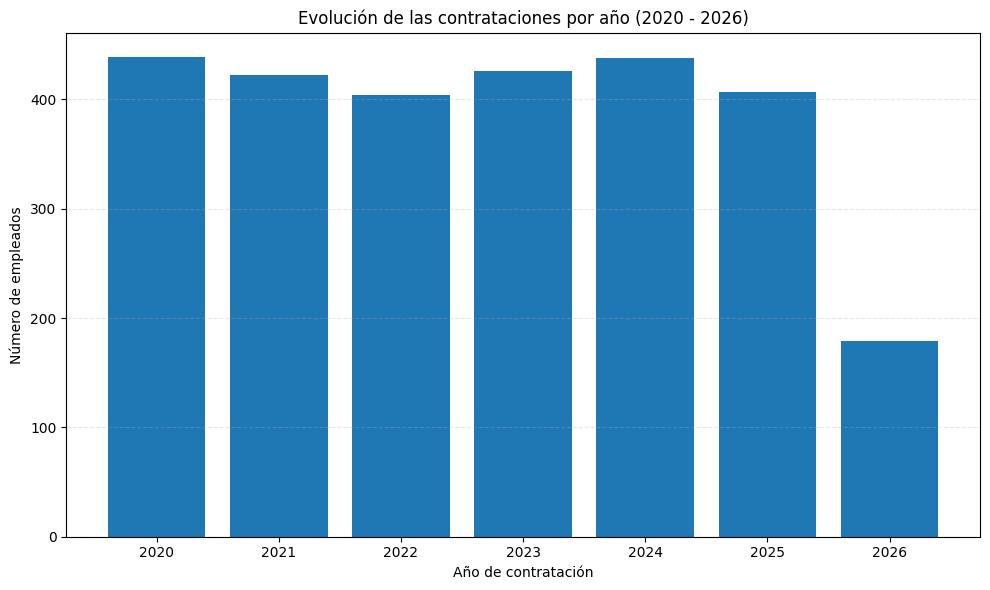

In [45]:
plt.figure(figsize=(10,6))

plt.bar(
    hiring_by_year.index.astype(str),
    hiring_by_year.values
)

plt.title("Evolución de las contrataciones por año (2020 - 2026)")
plt.xlabel("Año de contratación")
plt.ylabel("Número de empleados")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## Interpretación

La distribución de contrataciones entre 2020 y 2025 se mantiene relativamente estable, sin variaciones abruptas que sugieran inconsistencias en los datos.

El año 2024 presenta el mayor número de incorporaciones, mientras que la disminución observada en 2026 es esperable, ya que el período analizado finaliza el 10 de junio de dicho año y no contempla el año completo.

En conjunto, la evolución de las contrataciones resulta coherente con el escenario de crecimiento definido para GlobalStay Hotels.

## termination_date

## Auditoría de Integridad Temporal - Fecha de Baja (`termination_date`)

La columna `termination_date` representa la fecha en la que un empleado finalizó su relación laboral con la empresa.

Durante esta auditoría se verificará:

- Conversión correcta al tipo fecha.
- Existencia de bajas posteriores a la fecha de referencia del proyecto.
- Existencia de fechas de baja anteriores a la fecha de contratación.
- Coherencia general de la información temporal.

Conversión al tipo de fecha

In [46]:
df["termination_date"] = pd.to_datetime(df["termination_date"])

Resumen estadístico

In [47]:
df["termination_date"].describe()


count                              299
mean     2024-09-05 11:09:25.886287616
min                2020-03-18 00:00:00
25%                2023-11-14 12:00:00
50%                2024-11-23 00:00:00
75%                2025-11-14 12:00:00
max                2026-06-10 00:00:00
Name: termination_date, dtype: object

Buscar bajas futuras

In [ ]:
future_terminations = df[
    df["termination_date"] > "2026-06-10"
]


future_terminations

Columna,employee_id,first_name,last_name,gender,birth_date,hire_date,termination_date,status,hotel_code,hotel_name,city,country,department_code,department_name,contract_type,hierarchy_level,age,hire_year


In [51]:
len(future_terminations)


0

Buscar bajas anteriores a la contratación

In [52]:
termination_before_hire = df[
    df["termination_date"] < df["hire_date"]
]

termination_before_hire

Columna,employee_id,first_name,last_name,gender,birth_date,hire_date,termination_date,status,hotel_code,hotel_name,city,country,department_code,department_name,contract_type,hierarchy_level,age,hire_year


In [53]:
len(termination_before_hire)

0

Distribución de bajas por año

In [74]:
termination_by_year = (
    df["termination_date"]
    .dt.year
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

termination_by_year

termination_date
2020     3
2021     9
2022    25
2023    47
2024    76
2025    81
2026    58
Name: count, dtype: int64

Gráfico de bajas por año

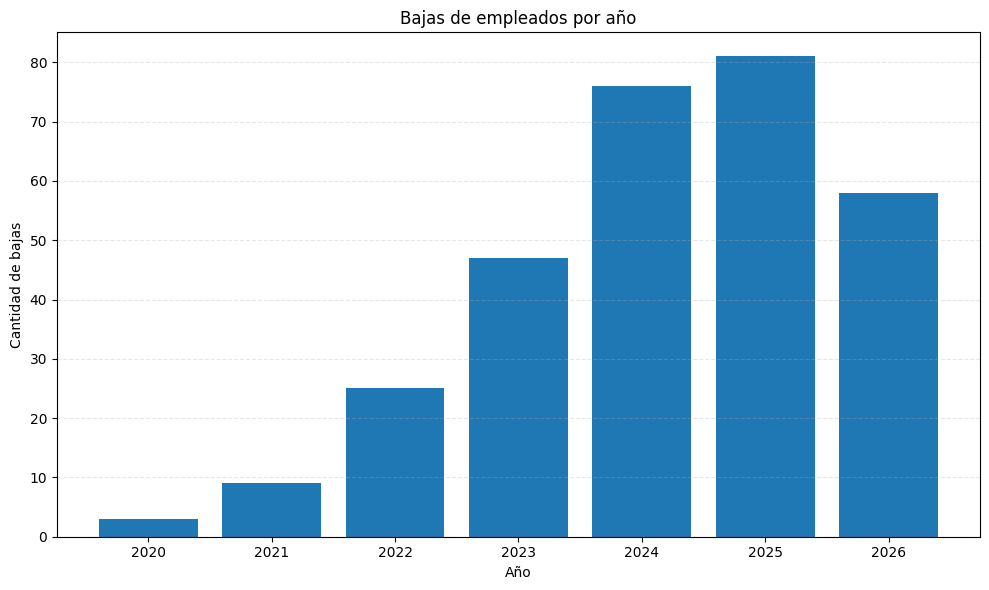

In [75]:
plt.figure(figsize=(10,6))

plt.bar(
    termination_by_year.index.astype(str),
    termination_by_year.values
)

plt.title("Bajas de empleados por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de bajas")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## Interpretación

La auditoría de la columna `termination_date` confirma que las fechas de baja presentan una alta consistencia temporal.

No se identificaron registros con fechas posteriores al período de referencia del proyecto ni casos en los que la fecha de baja sea anterior a la fecha de contratación.

La distribución anual muestra un incremento progresivo en el número de bajas, comportamiento consistente con el crecimiento de la plantilla durante los años analizados.

Estos resultados permiten considerar la columna `termination_date` apta para el cálculo de indicadores de rotación y permanencia del personal.

# 04 - Validación de reglas de negocio

In [56]:
# Regla 1: empleados activos no deberían tener fecha de baja

active_with_termination = df[
    (df["status"] == "Active") &
    (df["termination_date"].notna())
]

active_with_termination

Columna,employee_id,first_name,last_name,gender,birth_date,hire_date,termination_date,status,hotel_code,hotel_name,city,country,department_code,department_name,contract_type,hierarchy_level,age,hire_year


In [57]:
len(active_with_termination)

0

In [58]:
# Regla 2: empleados no activos deberían tener fecha de baja

inactive_without_termination = df[
    (df["status"] != "Active") &
    (df["termination_date"].isna())
]

inactive_without_termination

Columna,employee_id,first_name,last_name,gender,birth_date,hire_date,termination_date,status,hotel_code,hotel_name,city,country,department_code,department_name,contract_type,hierarchy_level,age,hire_year
9,EMP00010,Maria,Romero Martinez,Female,1967-09-01,2024-04-25,NaT,Long Leave,HES001,GlobalStay Palma Resort,Palma de Mallorca,Spain,FD,Front Desk,Permanent,Supervisor,58,2024
204,EMP00205,Pedro,Ramirez Gonzalez,Male,2003-02-17,2024-02-27,NaT,Long Leave,HES001,GlobalStay Palma Resort,Palma de Mallorca,Spain,SM,Sales & Marketing,Permanent,Supervisor,23,2024
235,EMP00236,Isabel,Perez Perez,Female,1980-08-11,2024-11-05,NaT,Long Leave,HES001,GlobalStay Palma Resort,Palma de Mallorca,Spain,FB,Food & Beverage,Permanent,Staff,45,2024
248,EMP00249,Isabel,Vargas Martinez,Female,1974-10-04,2021-01-16,NaT,Long Leave,HES001,GlobalStay Palma Resort,Palma de Mallorca,Spain,MT,Maintenance,Permanent,Staff,51,2021
409,EMP00410,Javier,Rodriguez Morales,Male,1988-12-31,2024-05-31,NaT,Long Leave,HES002,GlobalStay Madrid Business,Madrid,Spain,FB,Food & Beverage,Temporary,Staff,37,2024
501,EMP00502,Lucia,Gonzalez Torres,Female,1976-03-22,2023-02-07,NaT,Long Leave,HES002,GlobalStay Madrid Business,Madrid,Spain,FB,Food & Beverage,Permanent,Staff,50,2023
514,EMP00515,Fernando,Morales Martinez,Male,1985-09-02,2020-02-03,NaT,Long Leave,HES002,GlobalStay Madrid Business,Madrid,Spain,HK,Housekeeping,Permanent,Staff,40,2020
562,EMP00563,Lucia,Martinez Garcia,Female,1997-07-14,2024-07-23,NaT,Long Leave,HES002,GlobalStay Madrid Business,Madrid,Spain,HK,Housekeeping,Permanent,Supervisor,28,2024
649,EMP00650,Carlos,Ramirez Sanchez,Male,1983-01-24,2020-04-28,NaT,Long Leave,HES002,GlobalStay Madrid Business,Madrid,Spain,SW,Spa & Wellness,Permanent,Manager,43,2020
760,EMP00761,Miguel,Garcia Lopez,Male,1982-05-02,2021-12-26,NaT,Long Leave,HES003,GlobalStay Barcelona Beach,Barcelona,Spain,HR,Human Resources,Seasonal,Staff,44,2021


In [60]:
len(inactive_without_termination)

38

In [61]:
# Regla 3: la fecha de contratación debe ser posterior a la fecha de nacimiento

hire_before_birth = df[
    df["hire_date"] <= df["birth_date"]
]

hire_before_birth

Columna,employee_id,first_name,last_name,gender,birth_date,hire_date,termination_date,status,hotel_code,hotel_name,city,country,department_code,department_name,contract_type,hierarchy_level,age,hire_year
1282,EMP01283,Camila,Martinez Rodriguez,Female,2030-05-10,2022-03-30,NaT,Active,HMX001,GlobalStay Cancun Resort,Cancun,Mexico,SW,Spa & Wellness,Internship,Staff,-3,2022
1345,EMP01346,Isabel,Morales Rodriguez,Female,2030-05-10,2022-07-25,2023-02-03,Voluntary Termination,HMX001,GlobalStay Cancun Resort,Cancun,Mexico,FN,Finance,Internship,Manager,-3,2022
1557,EMP01558,Andres,Herrera Garcia,Male,2030-05-10,2021-02-02,NaT,Active,HMX002,GlobalStay Riviera Maya,Riviera Maya,Mexico,HK,Housekeeping,Permanent,Supervisor,-3,2021
1985,EMP01986,Alex,Rodriguez Sanchez,Non Binary,2030-05-10,2024-03-12,NaT,Active,HCU001,GlobalStay La Habana,La Habana,Cuba,HK,Housekeeping,Permanent,Staff,-3,2024
2511,EMP02512,Valentina,Garcia Castro,Female,2030-05-10,2023-02-14,NaT,Active,HDR001,GlobalStay Punta Cana Resort,Punta Cana,Dominican Republic,HK,Housekeeping,Permanent,Supervisor,-3,2023


In [62]:
len(hire_before_birth)

5

In [63]:
# Regla 4: la fecha de baja debe ser posterior a la fecha de contratación

termination_before_hire = df[
    df["termination_date"] < df["hire_date"]
]

termination_before_hire

Columna,employee_id,first_name,last_name,gender,birth_date,hire_date,termination_date,status,hotel_code,hotel_name,city,country,department_code,department_name,contract_type,hierarchy_level,age,hire_year


In [64]:
len(termination_before_hire)

0

In [65]:
# Regla 5: empleados menores de 18 años

underage_employees = df[
    df["age"] < 18
]

underage_employees

Columna,employee_id,first_name,last_name,gender,birth_date,hire_date,termination_date,status,hotel_code,hotel_name,city,country,department_code,department_name,contract_type,hierarchy_level,age,hire_year
1282,EMP01283,Camila,Martinez Rodriguez,Female,2030-05-10,2022-03-30,NaT,Active,HMX001,GlobalStay Cancun Resort,Cancun,Mexico,SW,Spa & Wellness,Internship,Staff,-3,2022
1345,EMP01346,Isabel,Morales Rodriguez,Female,2030-05-10,2022-07-25,2023-02-03,Voluntary Termination,HMX001,GlobalStay Cancun Resort,Cancun,Mexico,FN,Finance,Internship,Manager,-3,2022
1557,EMP01558,Andres,Herrera Garcia,Male,2030-05-10,2021-02-02,NaT,Active,HMX002,GlobalStay Riviera Maya,Riviera Maya,Mexico,HK,Housekeeping,Permanent,Supervisor,-3,2021
1985,EMP01986,Alex,Rodriguez Sanchez,Non Binary,2030-05-10,2024-03-12,NaT,Active,HCU001,GlobalStay La Habana,La Habana,Cuba,HK,Housekeeping,Permanent,Staff,-3,2024
2511,EMP02512,Valentina,Garcia Castro,Female,2030-05-10,2023-02-14,NaT,Active,HDR001,GlobalStay Punta Cana Resort,Punta Cana,Dominican Republic,HK,Housekeeping,Permanent,Supervisor,-3,2023


In [66]:
len(underage_employees)

5

In [67]:
from pathlib import Path

reports_path = Path("../reports/sprint_02")
reports_path.mkdir(parents=True, exist_ok=True)

In [68]:
# Guardar registros duplicados

duplicados.to_csv(
    reports_path / "duplicated_records.csv",
    index=False
)

In [69]:
# Guardar fechas de nacimiento futuras

future_birth_dates.to_csv(
    reports_path / "invalid_birth_dates.csv",
    index=False
)

In [70]:
# Guardar inconsistencias de género

gender_issues = df[
    df["gender"].isin(["male", "M", "F"])
]

gender_issues.to_csv(
    reports_path / "gender_inconsistencies.csv",
    index=False
)

In [71]:
# Guardar códigos de hotel no oficiales

invalid_hotel_codes = df[
    df["hotel_code"].isin(["PMI", "PALMA"])
]

invalid_hotel_codes.to_csv(
    reports_path / "invalid_hotel_codes.csv",
    index=False
)

In [72]:
# Guardar empleados menores de edad o con edad inválida

underage_employees.to_csv(
    reports_path / "underage_or_invalid_age_employees.csv",
    index=False
)

# Data Quality Scorecard

In [80]:
quality_scorecard.loc[
    quality_scorecard["Regla de calidad"] == "Activos sin fecha de baja",
    "Estado"
] = "Cumple" if len(active_with_termination) == 0 else "No cumple"

quality_scorecard.loc[
    quality_scorecard["Regla de calidad"] == "No activos con fecha de baja",
    "Estado"
] = "Cumple" if len(inactive_without_termination) == 0 else "No cumple"

quality_scorecard.loc[
    quality_scorecard["Regla de calidad"] == "Edad mínima laboral",
    "Estado"
] = "Cumple" if len(underage_employees) == 0 else "No cumple"

quality_scorecard

,Regla de calidad,Estado
0,Estructura del dataset,Cumple
1,Duplicados en employee_id,No cumple
2,Valores nulos obligatorios,Cumple
3,Estandarización de gender,No cumple
4,Catálogo oficial de hotel_code,No cumple
5,Fechas de nacimiento válidas,No cumple
6,Fechas de contratación válidas,Cumple
7,Fechas de baja válidas,Cumple
8,Activos sin fecha de baja,Cumple
9,No activos con fecha de baja,No cumple


In [78]:
total_checks = len(quality_scorecard)
passed_checks = len(quality_scorecard[quality_scorecard["Estado"] == "Cumple"])

data_quality_score = round((passed_checks / total_checks) * 100, 2)

print(f"Data Quality Score: {data_quality_score}%")

Data Quality Score: 45.45%


In [79]:
quality_scorecard.to_csv(
    reports_path / "data_quality_scorecard.csv",
    index=False
)

# Executive Summary

## Objetivo

El objetivo de este Sprint fue realizar una auditoría exploratoria y de calidad sobre el sistema HR Core de GlobalStay Hotels antes del diseño e implementación del proceso ETL y del Data Warehouse.

Durante esta etapa se evaluó la estructura del dataset, la calidad de los datos, la consistencia de los atributos, la integridad temporal y el cumplimiento de reglas de negocio.

---

# Alcance de la auditoría

La auditoría incluyó:

- Comprensión del dataset.
- Validación de la estructura.
- Análisis de duplicados.
- Análisis de valores nulos.
- Auditoría de atributos categóricos.
- Auditoría de Master Data.
- Auditoría de integridad temporal.
- Validación de reglas de negocio.

---

# Principales hallazgos

Se identificaron las siguientes incidencias:

- Registros duplicados en employee_id.
- Valores inconsistentes en la columna gender.
- Códigos de hotel no oficiales (PMI y PALMA).
- Cinco fechas de nacimiento posteriores a la fecha de referencia del proyecto.
- Treinta y ocho empleados con estado inactivo sin fecha de baja registrada.

Asimismo, se comprobó que:

- No existen bajas posteriores al período del proyecto.
- No existen bajas anteriores a la fecha de contratación.
- Los empleados activos no presentan fecha de baja registrada.

---

# Evaluación general

La estructura general del dataset es sólida y resulta adecuada para continuar con el desarrollo del proyecto.

Las inconsistencias detectadas corresponden principalmente a problemas de calidad de datos que podrán resolverse mediante reglas de transformación durante el proceso ETL.

No se identificaron problemas estructurales que impidan la construcción del Data Warehouse.

---

# Próximos pasos

Durante el Sprint 3 se desarrollará el proceso ETL para:

- Corregir registros duplicados.
- Estandarizar valores categóricos.
- Reconciliar códigos de hoteles.
- Corregir fechas inválidas.
- Implementar reglas automáticas de validación de calidad.
- Generar la capa limpia (Silver) que alimentará el Data Warehouse.